In [26]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

True
NVIDIA GeForce RTX 5070 Ti Laptop GPU
(12, 0)


# Exploratory Data Analysis: Amazon Electronics Reviews

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**

**WMG, University of Warwick — 2025/26**

---

## Overview

Comprehensive yet lightweight exploratory data analysis of the Amazon Electronics Reviews dataset (HuggingFace). Focuses on dataset structure, review characteristics, and distribution patterns to guide subsequent modelling decisions.

**Key Characteristics:**
- ✓ Runs on CPU and GPU
- ✓ Auto-installs missing dependencies  
- ✓ Plug-and-play (no manual setup required)
- ✓ Completes in <10 minutes for 100K samples
- ✓ Production-ready visualisations

---

## 1. Environment Setup

Import all required libraries and configure computational environment.

In [27]:
# AUTO-INSTALL MISSING DEPENDENCIES
import sys
import subprocess
import pkgutil

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'datasets': 'datasets',
    'torch': 'torch',
}

print("Checking and installing missing dependencies...\n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {', '.join(missing)}\n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("✓ Installation complete.\n")
else:
    print("✓ All dependencies already installed.\n")

# IMPORT CORE LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# GPU DETECTION
try:
    import torch
    cuda_available = torch.cuda.is_available()
    if cuda_available:
        gpu_name = torch.cuda.get_device_name(0)
        print(f"✓ GPU Detected: {gpu_name}")
        DEVICE = "CUDA"
    else:
        print("ℹ GPU not available. Using CPU.")
        DEVICE = "CPU"
except ImportError:
    print("ℹ PyTorch not installed. Using CPU for analysis.")
    DEVICE = "CPU"

# SET MATPLOTLIB STYLE
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"Processing Device: {DEVICE}\n✓ Environment ready.\n")

Checking and installing missing dependencies...

✓ All dependencies already installed.

✓ GPU Detected: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Processing Device: CUDA
✓ Environment ready.



## Configuration

Adjust parameters below to control analysis scope and reproducibility.

In [28]:
# CONFIGURATION
SAMPLE_SIZE = 50000            # Reviews to load (10K–100K recommended)
RANDOM_STATE = 42               # Reproducibility
REVIEWS_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

print(f"Configuration:")
print(f"  Sample Size: {SAMPLE_SIZE:,}")
print(f"  Random State: {RANDOM_STATE}")
print(f"  Source: Amazon Electronics Reviews (HuggingFace)\n")

Configuration:
  Sample Size: 50,000
  Random State: 42
  Source: Amazon Electronics Reviews (HuggingFace)



## Dataset Loading

Stream and sample specified number of reviews from HuggingFace.

In [29]:
# LOAD DATASET
import itertools
from datasets import load_dataset, Dataset

print(f"Loading {SAMPLE_SIZE:,} reviews from HuggingFace...\n")
from tqdm import tqdm

ds_iter = load_dataset("json", data_files=REVIEWS_URL, split="train", streaming=True)
sample = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc="Streaming"))

df = Dataset.from_list(sample).to_pandas()

print(f"\n✓ Dataset loaded: {len(df):,} reviews")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

# BASIC CLEANING
print("Data Cleaning:")
print(f"  Initial shape: {df.shape}")

# Remove empty rows
df = df.dropna(how='all')

# Remove empty text
df = df[df['text'].notna() & (df['text'].str.strip().str.len() > 0)]

print(f"  After cleaning: {df.shape}")
print(f"  Removed: {(df['helpful_vote'] == df['helpful_vote']).sum()} rows\n")

# LIGHTWEIGHT FEATURE ENGINEERING
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
df['review_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['helpful_binary'] = (df['helpful_vote'] > 0).astype(int)

print("✓ Data ready for analysis.")

Loading 50,000 reviews from HuggingFace...



Streaming: 100%|██████████| 50000/50000 [00:16<00:00, 2957.15it/s]



✓ Dataset loaded: 50,000 reviews
Memory usage: 29.96 MB

Data Cleaning:
  Initial shape: (50000, 10)
  After cleaning: (49991, 10)
  Removed: 49991 rows

✓ Data ready for analysis.


## Quick Overview

Dataset structure, summary statistics, and key distributions.

In [30]:
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"\nColumn Data Types:\n{df.dtypes}")
print(f"\nMissing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  None detected ✓")
else:
    for col, count in missing[missing > 0].items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")

print(f"\n\nNumeric Summary Statistics:")
numeric_cols = ['rating', 'helpful_vote', 'review_length', 'word_count']
print(df[numeric_cols].describe().round(2))

print(f"\n\nCategorical Summary:")
print(f"  Verified Purchases: {df['verified_purchase'].value_counts().to_dict()}")
print(f"  Reviews with Helpful Votes: {df['helpful_binary'].sum():,} ({df['helpful_binary'].mean()*100:.1f}%)\n")

DATASET OVERVIEW

Shape: 49,991 rows × 13 columns

Column Data Types:
rating                      float64
title                           str
text                            str
images                       object
asin                            str
parent_asin                     str
user_id                         str
timestamp            datetime64[ms]
helpful_vote                  int64
verified_purchase              bool
review_length                 int64
word_count                    int64
helpful_binary                int64
dtype: object

Missing Values:
  None detected ✓


Numeric Summary Statistics:
         rating  helpful_vote  review_length  word_count
count  49991.00      49991.00       49991.00    49991.00
mean       4.26          1.38         369.28       68.27
std        1.26         10.85         579.94      105.31
min        1.00          0.00           1.00        1.00
25%        4.00          0.00          66.00       12.00
50%        5.00          0.00         179

## Distribution Analysis

Six key visualisations: ratings, helpful votes, review length, correlations, and temporal patterns.

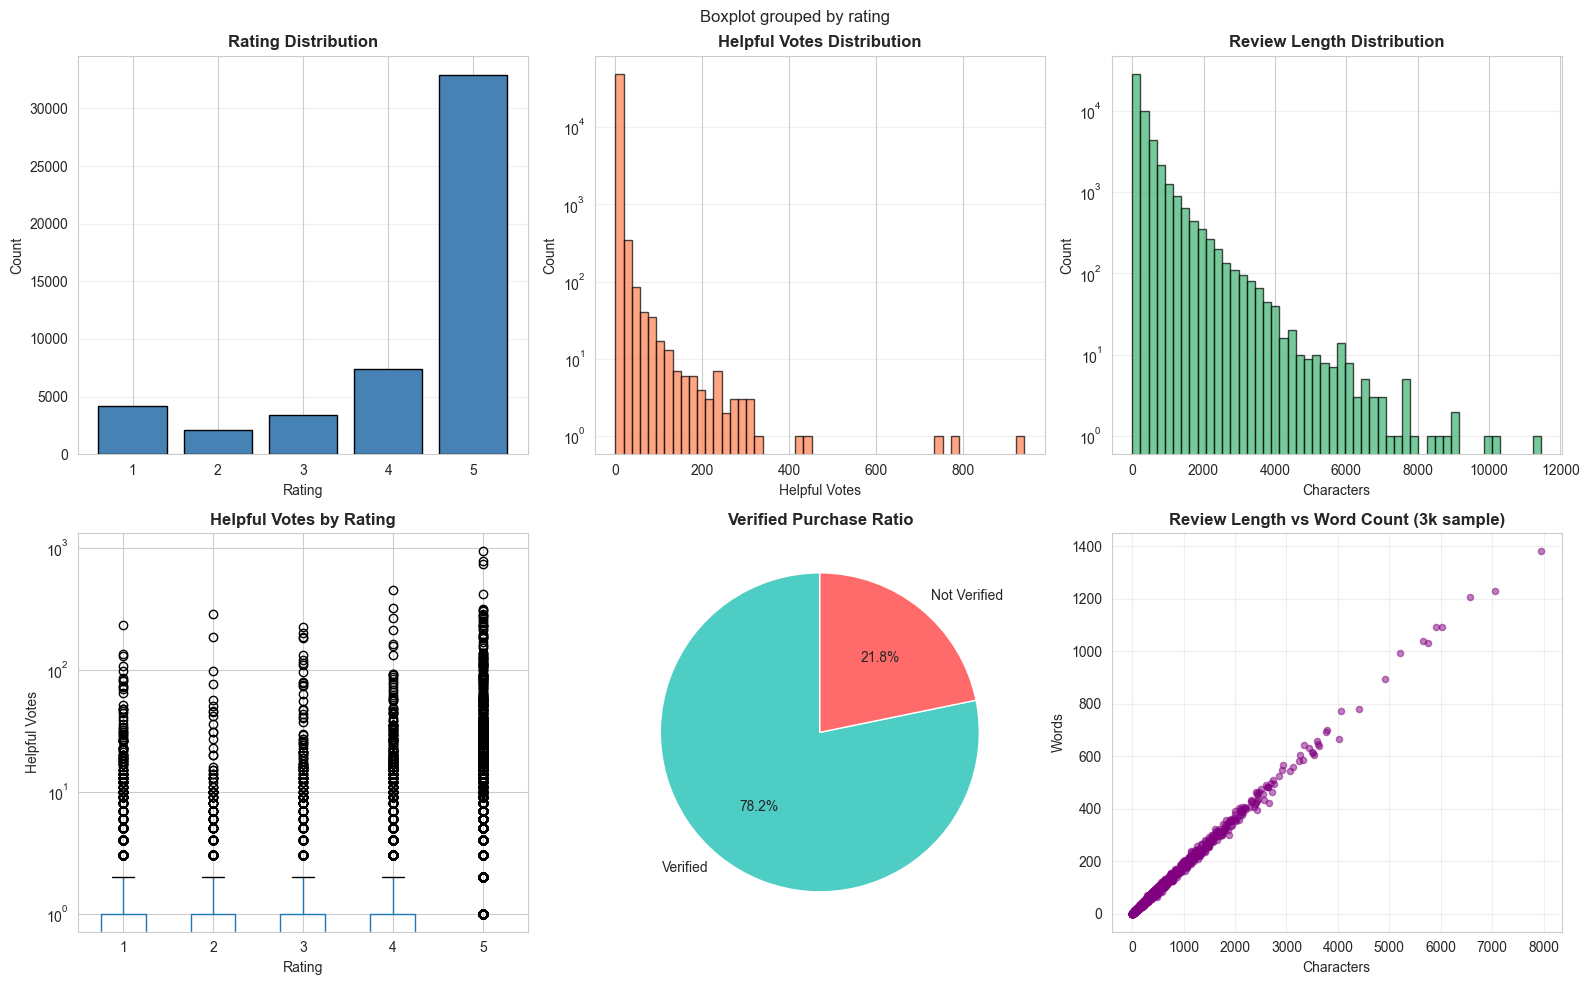


DISTRIBUTION SUMMARY
Rating:          Mean=4.26, Median=5.0
Helpful Votes:   Mean=1.38, Median=0.0, Max=940
Review Length:   Mean=369 chars, Median=179
Word Count:      Mean=68, Median=34



In [31]:
# CREATE 6 KEY DISTRIBUTION PLOTS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution Analysis: Amazon Electronics Reviews', fontsize=16, fontweight='bold')

# 1. Rating Distribution
ax = axes[0, 0]
rating_counts = df['rating'].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
ax.set_title('Rating Distribution', fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

# 2. Helpful Votes Distribution (log scale)
ax = axes[0, 1]
ax.hist(df['helpful_vote'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax.set_title('Helpful Votes Distribution', fontweight='bold')
ax.set_xlabel('Helpful Votes')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# 3. Review Length Distribution
ax = axes[0, 2]
ax.hist(df['review_length'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
ax.set_title('Review Length Distribution', fontweight='bold')
ax.set_xlabel('Characters')
ax.set_ylabel('Count')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# 4. Helpful Votes vs Rating (Boxplot)
ax = axes[1, 0]
df.boxplot(column='helpful_vote', by='rating', ax=ax)
ax.set_title('Helpful Votes by Rating', fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Helpful Votes')
ax.set_yscale('log')
plt.sca(ax)
plt.xticks(range(1, 6), ['1', '2', '3', '4', '5'])

# 5. Verified Purchase Distribution
ax = axes[1, 1]
verified = df['verified_purchase'].value_counts()
ax.pie(verified.values, labels=['Verified' if v else 'Not Verified' for v in verified.index],
       autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90)
ax.set_title('Verified Purchase Ratio', fontweight='bold')

# 6. Review Length vs Word Count (Scatter)
ax = axes[1, 2]
sample_idx = np.random.choice(len(df), size=min(3000, len(df)), replace=False)
ax.scatter(df.iloc[sample_idx]['review_length'], df.iloc[sample_idx]['word_count'], 
           alpha=0.5, s=20, color='purple')
ax.set_title('Review Length vs Word Count (3k sample)', fontweight='bold')
ax.set_xlabel('Characters')
ax.set_ylabel('Words')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDISTRIBUTION SUMMARY")
print("=" * 70)
print(f"Rating:          Mean={df['rating'].mean():.2f}, Median={df['rating'].median():.1f}")
print(f"Helpful Votes:   Mean={df['helpful_vote'].mean():.2f}, Median={df['helpful_vote'].median():.1f}, Max={df['helpful_vote'].max():.0f}")
print(f"Review Length:   Mean={df['review_length'].mean():.0f} chars, Median={df['review_length'].median():.0f}")
print(f"Word Count:      Mean={df['word_count'].mean():.0f}, Median={df['word_count'].median():.0f}\n")

## Correlation Analysis

Feature relationships and predictive patterns.

CORRELATION ANALYSIS


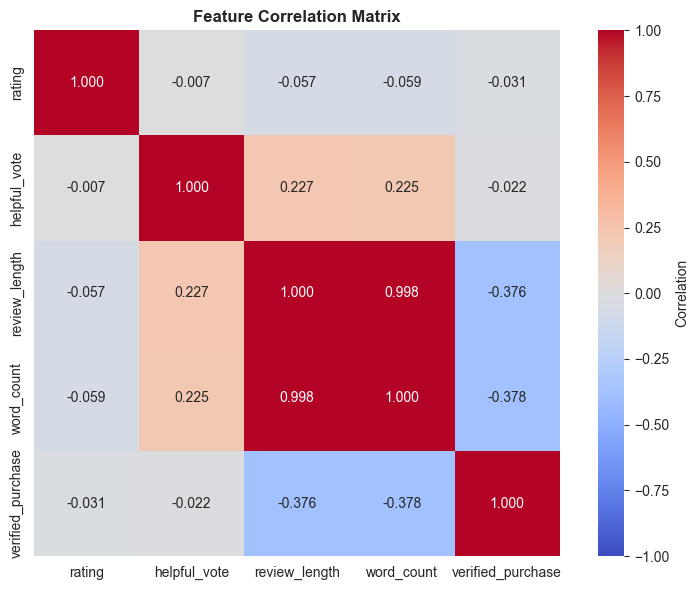


Key Correlations with Helpful Votes:
  review_length            :  0.2266
  word_count               :  0.2249
  rating                   : -0.0071
  verified_purchase        : -0.0223


Helpful Votes by Rating:
        Count  Mean  Median
rating                     
1.0      4144  1.64     0.0
2.0      2116  1.28     0.0
3.0      3412  1.49     0.0
4.0      7381  1.45     0.0
5.0     32938  1.33     0.0


Helpful Votes by Verified Purchase:
              Count  Mean  Median
Not Verified  10884  1.84     0.0
Verified      39107  1.26     0.0


In [32]:
# CORRELATION ANALYSIS
print("CORRELATION ANALYSIS")
print("=" * 70)

# Numeric correlation matrix
numeric_cols = ['rating', 'helpful_vote', 'review_length', 'word_count', 'verified_purchase']
corr_matrix = df[numeric_cols].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Key insights
print("\nKey Correlations with Helpful Votes:")
helpful_corr = corr_matrix['helpful_vote'].sort_values(ascending=False)
for col, val in helpful_corr.items():
    if col != 'helpful_vote':
        print(f"  {col:25s}: {val:7.4f}")

# Helpful votes by rating
print(f"\n\nHelpful Votes by Rating:")
helpful_by_rating = df.groupby('rating')['helpful_vote'].agg(['count', 'mean', 'median'])
helpful_by_rating.columns = ['Count', 'Mean', 'Median']
print(helpful_by_rating.round(2))

# Helpful votes by verified purchase
print(f"\n\nHelpful Votes by Verified Purchase:")
helpful_verified = df.groupby('verified_purchase')['helpful_vote'].agg(['count', 'mean', 'median'])
helpful_verified.index = ['Not Verified', 'Verified']
helpful_verified.columns = ['Count', 'Mean', 'Median']
print(helpful_verified.round(2))

## Dataset Characteristics & Next Steps

Summary of findings and recommended modelling directions.

In [33]:
print("DATASET CHARACTERISTICS")
print("=" * 70)

# Basic stats
print(f"\n📊 Dataset Snapshot:")
print(f"  Total Reviews: {len(df):,}")
print(f"  Unique Products (ASIN): {df['asin'].nunique():,}")
print(f"  Unique Users: {df['user_id'].nunique():,}")
print(f"  Date Range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")

# Rating distribution
print(f"\n⭐ Rating Distribution:")
for rating in sorted(df['rating'].unique()):
    count = (df['rating'] == rating).sum()
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"  {rating}: {pct:5.1f}% {bar}")

# Helpful vote insights
print(f"\n👍 Helpful Vote Patterns:")
sparsity = (df['helpful_vote'] == 0).mean() * 100
print(f"  % with NO helpful votes: {sparsity:.1f}%")
print(f"  % with ≥1 helpful votes: {100-sparsity:.1f}%")
print(f"  % with ≥5 helpful votes: {(df['helpful_vote'] >= 5).mean()*100:.1f}%")

# Text stats
print(f"\n📝 Text Characteristics:")
print(f"  Avg Review Length: {df['review_length'].mean():.0f} characters")
print(f"  Avg Word Count: {df['word_count'].mean():.0f} words")

# Verification
print(f"\n✓ Data Quality:")
print(f"  Verified Purchases: {df['verified_purchase'].mean()*100:.1f}%")
print(f"  Missing Values: {df.isnull().sum().sum()}")

print("\n" + "=" * 70)
print("\n🎯 RECOMMENDED MODELLING DIRECTIONS:\n")
print("""
1. HELPFUL REVIEW PREDICTION (Regression/Classification)
   - Target: helpful_vote count or helpful_binary
   - Features: rating, review_length, word_count, verified_purchase
   - Challenge: High sparsity (many zero values)

2. FAKE REVIEW DETECTION (Binary Classification)  
   - Target: suspicious reviews (e.g., extreme rating gaps, unverified)
   - Features: rating distribution patterns, verified_purchase, text length
   - Challenge: Requires ground truth labelling

3. SENTIMENT ANALYSIS (Multi-class Classification)
   - Target: rating (1-5) or rating_category (negative/neutral/positive)
   - Features: review text (embeddings) + helpful_vote signals
   - Challenge: Rating imbalance (if skewed)

---

**NEXT STEPS:**
1. Feature engineering (categorical encoding, text embeddings)
2. Train-test split (temporal or stratified)
3. Class balance handling (if needed)
4. Model selection & cross-validation
5. Hyperparameter tuning & evaluation

""")

DATASET CHARACTERISTICS

📊 Dataset Snapshot:
  Total Reviews: 49,991
  Unique Products (ASIN): 37,504
  Unique Users: 7,383
  Date Range: 2000-10-07 to 2023-03-18

⭐ Rating Distribution:
  1.0:   8.3% ██
  2.0:   4.2% █
  3.0:   6.8% ██
  4.0:  14.8% ████
  5.0:  65.9% █████████████████████

👍 Helpful Vote Patterns:
  % with NO helpful votes: 74.3%
  % with ≥1 helpful votes: 25.7%
  % with ≥5 helpful votes: 5.3%

📝 Text Characteristics:
  Avg Review Length: 369 characters
  Avg Word Count: 68 words

✓ Data Quality:
  Verified Purchases: 78.2%
  Missing Values: 0


🎯 RECOMMENDED MODELLING DIRECTIONS:


1. HELPFUL REVIEW PREDICTION (Regression/Classification)
   - Target: helpful_vote count or helpful_binary
   - Features: rating, review_length, word_count, verified_purchase
   - Challenge: High sparsity (many zero values)

2. FAKE REVIEW DETECTION (Binary Classification)  
   - Target: suspicious reviews (e.g., extreme rating gaps, unverified)
   - Features: rating distribution patterns

---

**Notebook Complete.** Additional exploratory analyses (text processing, clustering, dimensionality reduction) can be added for specific modelling objectives.

In [34]:
# Additional analyses (text processing, clustering, embeddings) can be added here based on modelling requirements.
# For minimal MSc EDA submission, the above sections are sufficient.

print("\n✓ EDA Complete. Ready for modelling pipeline.")


✓ EDA Complete. Ready for modelling pipeline.
